# PPO LunarLander — Results Showcase

This notebook loads the trained checkpoint, evaluates it, visualizes training curves parsed from a saved training log, and plots the return distribution.

**Requirements before running:**
- `results/checkpoints/ppo_final.pt` and `results/checkpoints/obs_rms.npz` must exist (produced by `train.py`)
- A training log file (e.g. `run_v5.log`, produced via `python train.py ... > run_v5.log 2>&1`) should be placed next to this notebook, or update `LOG_PATH` below
- Run this notebook from the `src/` directory (same convention as `train.py` / `evaluate.py`), so relative paths to `results/` resolve correctly

In [17]:
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from config import PPOConfig
from evaluate import evaluate

# --- Paths (adjust if your layout differs) ---
CHECKPOINT_PATH = "results/checkpoints/ppo_final.pt"
OBS_RMS_PATH = "results/checkpoints/obs_rms.npz"
LOG_PATH = "run.log"  # the training log used to plot learning curves below

plt.rcParams["figure.dpi"] = 110

## 1. Run evaluation

Loads the trained policy and runs it deterministically (using the Gaussian's mean, not sampled actions) for a number of episodes, reusing the exact same `evaluate()` function from `evaluate.py` — no logic is duplicated here.

In [18]:
cfg = PPOConfig()

assert os.path.exists(CHECKPOINT_PATH), (
    f"Checkpoint not found at {CHECKPOINT_PATH}. "
    "Run train.py first, or update CHECKPOINT_PATH above."
)

N_EVAL_EPISODES = 250

stats = evaluate(
    checkpoint_path=CHECKPOINT_PATH,
    cfg=cfg,
    num_episodes=N_EVAL_EPISODES,
    deterministic=True,
    render=False,
    obs_rms_path=OBS_RMS_PATH if os.path.exists(OBS_RMS_PATH) else None,
)
stats

Loaded observation normalization stats from results/checkpoints/obs_rms.npz
Episode 1/250: return = 259.97
Episode 2/250: return = 134.24
Episode 3/250: return = 174.62
Episode 4/250: return = 128.82
Episode 5/250: return = 178.69
Episode 6/250: return = 147.15
Episode 7/250: return = 130.24
Episode 8/250: return = 142.08
Episode 9/250: return = 260.90
Episode 10/250: return = 264.11
Episode 11/250: return = 283.47
Episode 12/250: return = 132.83
Episode 13/250: return = 271.35
Episode 14/250: return = 280.64
Episode 15/250: return = 169.41
Episode 16/250: return = 166.81
Episode 17/250: return = 155.96
Episode 18/250: return = 260.75
Episode 19/250: return = 142.83
Episode 20/250: return = 131.70
Episode 21/250: return = 138.67
Episode 22/250: return = 260.13
Episode 23/250: return = 142.12
Episode 24/250: return = 284.50
Episode 25/250: return = 269.72
Episode 26/250: return = 270.92
Episode 27/250: return = 154.29
Episode 28/250: return = 24.92
Episode 29/250: return = 282.53
Episod

{'mean_return': 205.06734983082754,
 'std_return': 60.82607031432756,
 'min_return': 24.915081921923587,
 'max_return': 305.0741991685136}

## 2. Return distribution

`evaluate()` only returns summary statistics (mean/std/min/max), so for a per-episode distribution plot we re-run evaluation episode by episode here, reusing the same loading/eval logic from `evaluate.py` directly.

In [19]:
from evaluate import make_eval_env
from ppo_agent import ActorCritic
import gymnasium as gym

device = torch.device(cfg.device)
env = make_eval_env(
    cfg.env_id, cfg.normalize_obs, cfg.seed, render=False, video_dir="",
    obs_rms_path=OBS_RMS_PATH if os.path.exists(OBS_RMS_PATH) else None,
)

obs_space = env.observation_space
action_space = env.action_space
assert isinstance(obs_space, gym.spaces.Box) and isinstance(action_space, gym.spaces.Box)

network = ActorCritic(
    obs_dim=int(np.prod(obs_space.shape)),
    action_dim=int(np.prod(action_space.shape)),
    hidden_size=cfg.hidden_size,
    num_hidden_layers=cfg.num_hidden_layers,
    log_std_init=cfg.log_std_init,
).to(device)
network.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
network.eval()

returns = []
with torch.no_grad():
    for ep in range(N_EVAL_EPISODES):
        obs, _ = env.reset(seed=cfg.seed + ep)
        done = False
        ep_return = 0.0
        info = {}
        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            action = network.actor_mean(obs_t).squeeze(0)
            clipped = torch.clamp(
                action,
                torch.tensor(action_space.low, device=device),
                torch.tensor(action_space.high, device=device),
            )
            obs, reward, terminated, truncated, info = env.step(clipped.cpu().numpy())
            done = terminated or truncated
            ep_return += float(reward)
        if "episode" in info:
            ep_return = float(info["episode"]["r"])
        returns.append(ep_return)
env.close()

returns = np.array(returns)
print(f"mean={returns.mean():.2f} +/- {returns.std():.2f}  (min={returns.min():.2f}, max={returns.max():.2f})")

Loaded observation normalization stats from results/checkpoints/obs_rms.npz
mean=205.07 +/- 60.83  (min=24.92, max=305.07)


/tmp/ipykernel_4384/527756121.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(returns, vert=True)


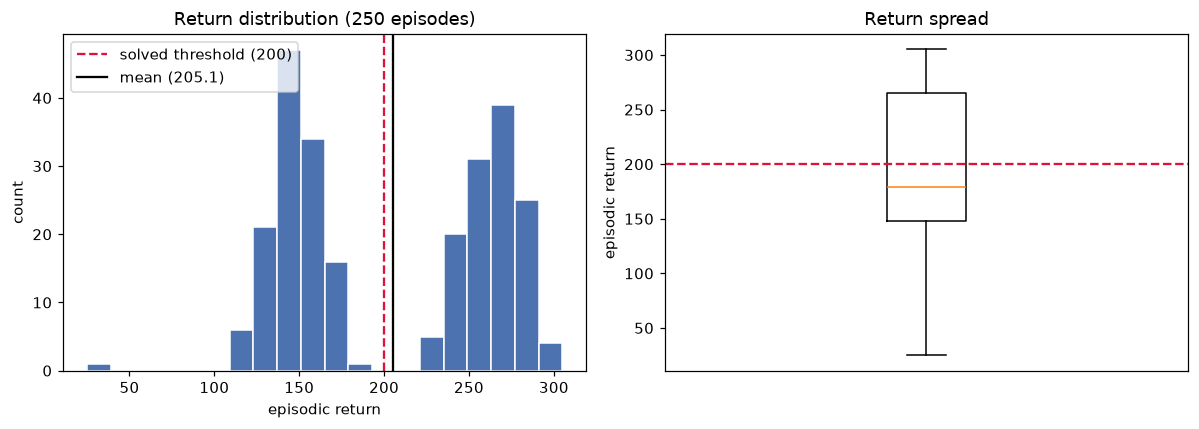

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(returns, bins=20, color="#4C72B0", edgecolor="white")
axes[0].axvline(200, color="crimson", linestyle="--", label="solved threshold (200)")
axes[0].axvline(returns.mean(), color="black", linestyle="-", label=f"mean ({returns.mean():.1f})")
axes[0].set_xlabel("episodic return")
axes[0].set_ylabel("count")
axes[0].set_title(f"Return distribution ({N_EVAL_EPISODES} episodes)")
axes[0].legend()

axes[1].boxplot(returns, vert=True)
axes[1].axhline(200, color="crimson", linestyle="--")
axes[1].set_ylabel("episodic return")
axes[1].set_title("Return spread")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## 3. Training curves

Parses the per-update metrics PPO logs to stdout during training (see `train.py`'s log line: `update=... step=... policy_loss=... value_loss=... entropy=... approx_kl=... ent_coef=...`) directly out of a saved log file — no need to re-run training.

In [21]:
def parse_training_log(log_path: str) -> pd.DataFrame:
    """
    Extract per-update and per-episode metrics from a train.py log file.

    Two line formats are parsed:
      - update lines:  'update=12/305 step=196608 sps=4389 policy_loss=... value_loss=... entropy=... approx_kl=... ent_coef=...'
      - episode lines: 'global_step=478592, episodic_return=18.18'
    """
    update_pattern = re.compile(
        r"update=(?P<update>\d+)/\d+ step=(?P<step>\d+) sps=(?P<sps>\d+) "
        r"policy_loss=(?P<policy_loss>-?\d+\.\d+) value_loss=(?P<value_loss>-?\d+\.\d+) "
        r"entropy=(?P<entropy>-?\d+\.\d+) approx_kl=(?P<approx_kl>-?\d+\.\d+)"
        r"(?: ent_coef=(?P<ent_coef>-?\d+\.\d+))?"
    )
    episode_pattern = re.compile(
        r"global_step=(?P<step>\d+), episodic_return=(?P<episodic_return>-?\d+\.\d+)"
    )

    updates, episodes = [], []
    with open(log_path) as f:
        for line in f:
            m = update_pattern.search(line)
            if m:
                row = {k: float(v) if v is not None else np.nan for k, v in m.groupdict().items()}
                updates.append(row)
                continue
            m = episode_pattern.search(line)
            if m:
                episodes.append({k: float(v) for k, v in m.groupdict().items()})

    return pd.DataFrame(updates), pd.DataFrame(episodes)


if os.path.exists(LOG_PATH):
    updates_df, episodes_df = parse_training_log(LOG_PATH)
    print(f"Parsed {len(updates_df)} update rows and {len(episodes_df)} episode rows from {LOG_PATH}")
else:
    updates_df, episodes_df = pd.DataFrame(), pd.DataFrame()
    print(f"No log file found at {LOG_PATH} — set LOG_PATH to a saved train.py log to see training curves.")

Parsed 1525 update rows and 35917 episode rows from run.log


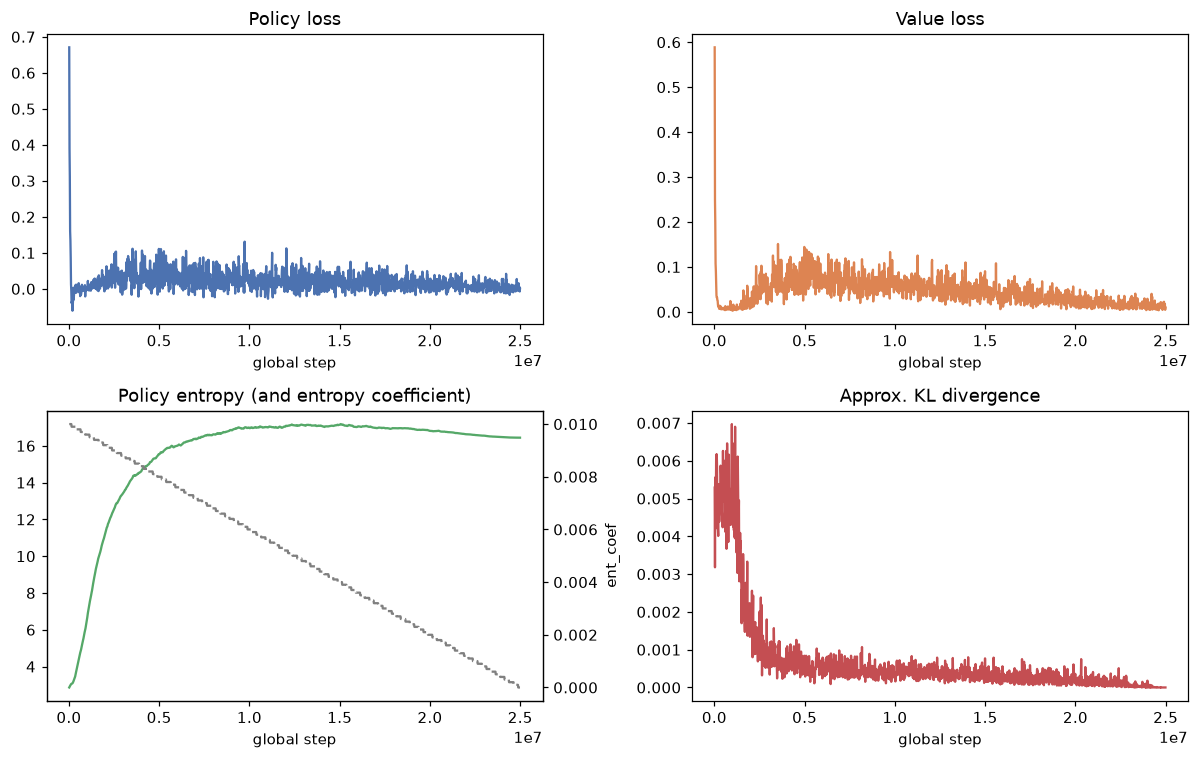

In [22]:
if not updates_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].plot(updates_df["step"], updates_df["policy_loss"], color="#4C72B0")
    axes[0, 0].set_title("Policy loss")
    axes[0, 0].set_xlabel("global step")

    axes[0, 1].plot(updates_df["step"], updates_df["value_loss"], color="#DD8452")
    axes[0, 1].set_title("Value loss")
    axes[0, 1].set_xlabel("global step")

    axes[1, 0].plot(updates_df["step"], updates_df["entropy"], color="#55A868", label="entropy")
    if updates_df["ent_coef"].notna().any():
        ax2 = axes[1, 0].twinx()
        ax2.plot(updates_df["step"], updates_df["ent_coef"], color="gray", linestyle="--", label="ent_coef")
        ax2.set_ylabel("ent_coef")
    axes[1, 0].set_title("Policy entropy (and entropy coefficient)")
    axes[1, 0].set_xlabel("global step")

    axes[1, 1].plot(updates_df["step"], updates_df["approx_kl"], color="#C44E52")
    axes[1, 1].set_title("Approx. KL divergence")
    axes[1, 1].set_xlabel("global step")

    plt.tight_layout()
    plt.show()
else:
    print("Skipping: no training log loaded.")

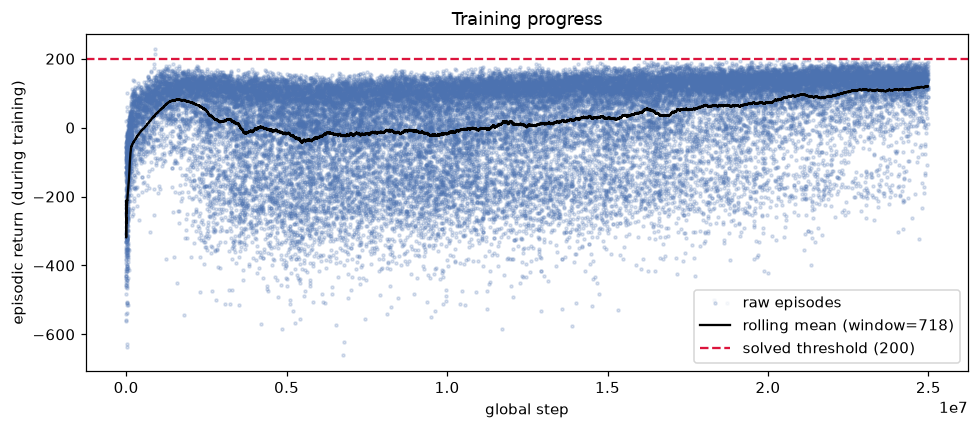

In [23]:
if not episodes_df.empty:
    # Rolling mean smooths the highly noisy per-episode return signal,
    # making the overall learning trend visible.
    window = max(1, len(episodes_df) // 50)
    rolling = episodes_df["episodic_return"].rolling(window=window, min_periods=1).mean()

    plt.figure(figsize=(9, 4))
    plt.scatter(episodes_df["step"], episodes_df["episodic_return"], s=4, alpha=0.2, color="#4C72B0", label="raw episodes")
    plt.plot(episodes_df["step"], rolling, color="black", linewidth=1.5, label=f"rolling mean (window={window})")
    plt.axhline(200, color="crimson", linestyle="--", label="solved threshold (200)")
    plt.xlabel("global step")
    plt.ylabel("episodic return (during training)")
    plt.title("Training progress")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: no per-episode data found in the log (episodes may not have completed within logged rollouts).")

## 4. Demo

Inline playback of a recorded evaluation episode. Generate it first with:
```bash
python evaluate.py --episodes 1 --render
```
or embed the curated `assets/demo.gif` shown in the README.

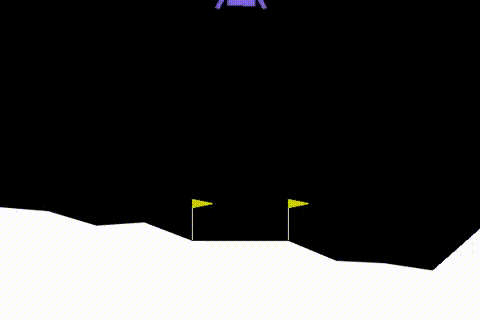

In [24]:
from IPython.display import Image, Video, display

gif_path = "../assets/demo.gif"
video_dir = "results/videos"

if os.path.exists(gif_path):
    display(Image(filename=gif_path))
elif os.path.isdir(video_dir):
    mp4s = sorted(f for f in os.listdir(video_dir) if f.endswith(".mp4"))
    if mp4s:
        display(Video(os.path.join(video_dir, mp4s[-1]), embed=True, width=480))
    else:
        print(f"No .mp4 files found in {video_dir}. Run: python evaluate.py --episodes 1 --render")
else:
    print(f"No demo found at {gif_path} or {video_dir}.")

## Summary

`LunarLanderContinuous-v3` is considered solved at a mean return ≥ 200 over 100 consecutive episodes. This policy's evaluation statistics are printed in section 1 above.